In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv('../data/processed/df_cleaned.csv')

with open('../src/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../src/features.pkl', 'rb') as f:
    FEATURES = pickle.load(f)

X = df[FEATURES]
y = df['risk_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

CLASS_NAMES = ['Low', 'Medium', 'High']
PALETTE     = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER       = ['Low', 'Medium', 'High']

print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print(f"Features: {len(FEATURES)}")

X_train : (36000, 19)
X_test  : (9000, 19)
Features: 19


In [4]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
}

print("Models defined:")
for name in models:
    print(f"- {name}")

Models defined:
- Random Forest
- XGBoost
- Logistic Regression


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_validate(
        model, X_train_scaled, y_train,
        cv=cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
        return_train_score=True
    )

    print(f"\n{name}")
    print(f"{'-'*45}")
    print(f"CV Accuracy: {scores['test_accuracy'].mean():.4f} +- {scores['test_accuracy'].std():.4f}")
    print(f"CV F1 (macro): {scores['test_f1_macro'].mean():.4f} +- {scores['test_f1_macro'].std():.4f}")
    print(f"CV ROC-AUC: {scores['test_roc_auc_ovr_weighted'].mean():.4f} +- {scores['test_roc_auc_ovr_weighted'].std():.4f}")


Random Forest
---------------------------------------------
CV Accuracy: 0.9997 +- 0.0001
CV F1 (macro): 0.9997 +- 0.0001
CV ROC-AUC: 1.0000 +- 0.0000

XGBoost
---------------------------------------------
CV Accuracy: 0.9974 +- 0.0007
CV F1 (macro): 0.9974 +- 0.0007
CV ROC-AUC: 1.0000 +- 0.0000

Logistic Regression
---------------------------------------------
CV Accuracy: 0.9889 +- 0.0008
CV F1 (macro): 0.9889 +- 0.0008
CV ROC-AUC: 0.9999 +- 0.0000


In [6]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_prob, multi_class='ovr', average='weighted'
    )

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'roc_auc': roc,
    }

    print(f"\n{name} — Test Set Results")
    print(f"{'-'*45}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=CLASS_NAMES)}")


Random Forest — Test Set Results
---------------------------------------------
Accuracy: 0.9999
ROC-AUC: 1.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3000
      Medium       1.00      1.00      1.00      3000
        High       1.00      1.00      1.00      3000

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000


XGBoost — Test Set Results
---------------------------------------------
Accuracy: 0.9976
ROC-AUC: 1.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3000
      Medium       1.00      1.00      1.00      3000
        High       1.00      1.00      1.00      3000

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000


Logistic Regres

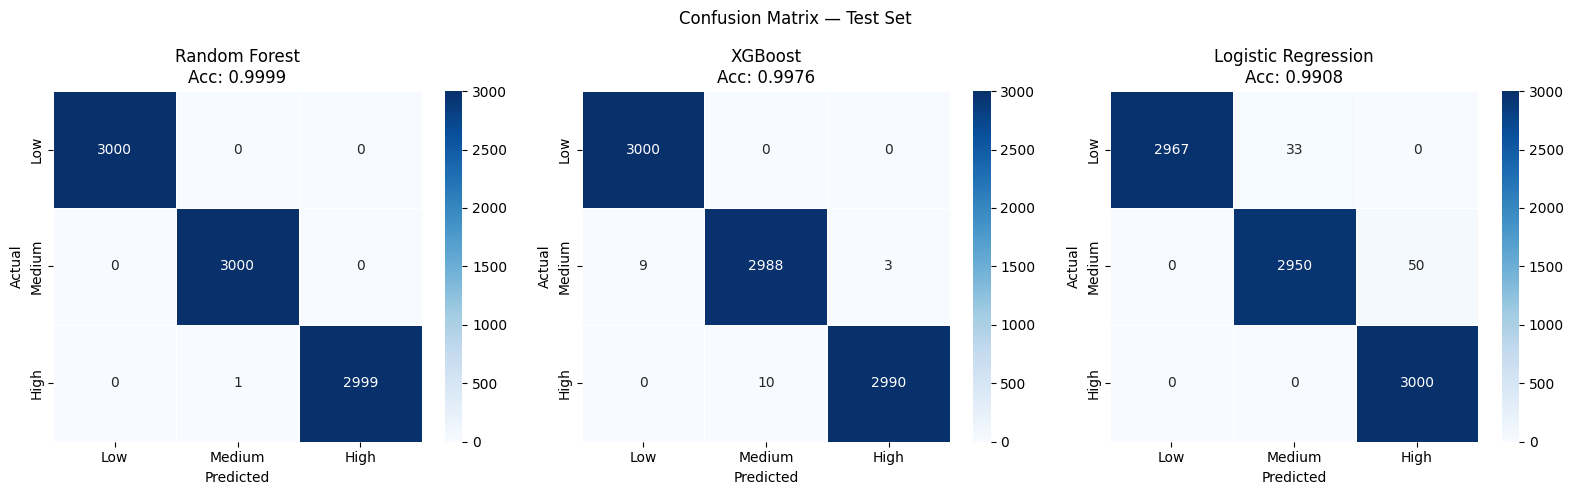

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrix — Test Set")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', bbox_inches='tight')
plt.show()

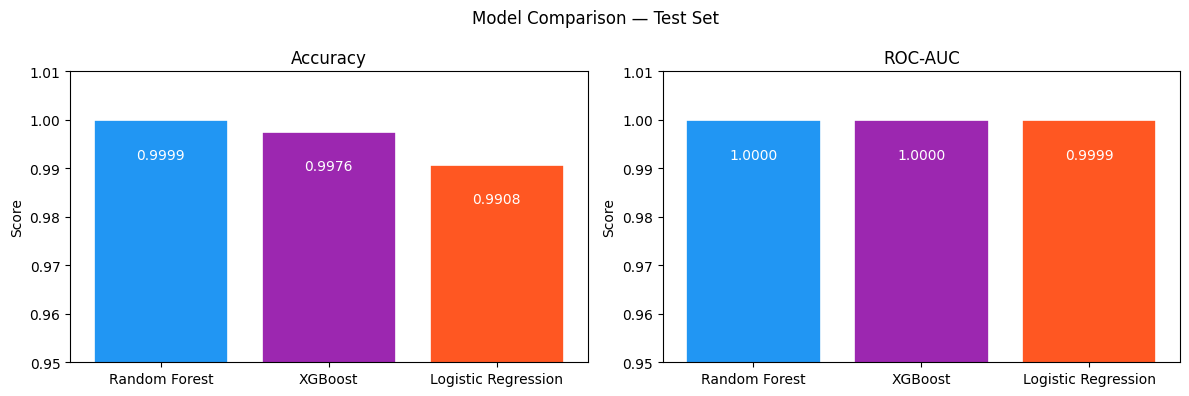

In [8]:
model_names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in model_names]
roc_aucs = [results[n]['roc_auc'] for n in model_names]
colors = ['#2196F3', '#9C27B0', '#FF5722']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Comparison — Test Set")

for ax, values, label in zip(axes, [accuracies, roc_aucs], ['Accuracy', 'ROC-AUC']):
    bars = ax.bar(model_names, values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.008,
                f"{val:.4f}", ha='center', color='white')
    ax.set_title(label)
    ax.set_ylim(0.95, 1.01)
    ax.set_ylabel("Score")

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', bbox_inches='tight')
plt.show()

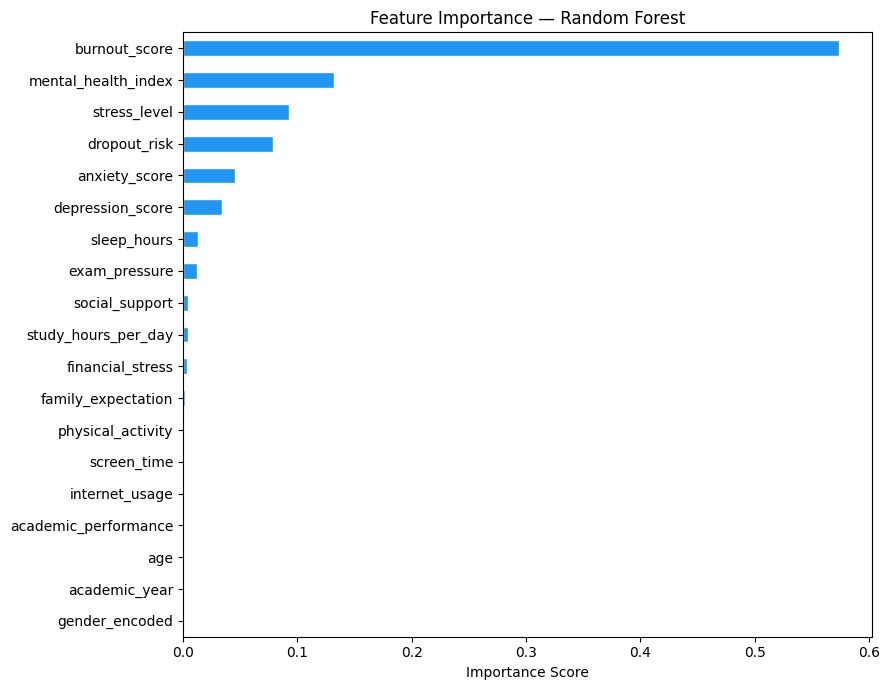

Top 5 features:
burnout_score          0.5737
mental_health_index    0.1323
stress_level           0.0930
dropout_risk           0.0783
anxiety_score          0.0456
dtype: float64


In [9]:
# feature importance
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_,
                        index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head(5).round(4))

In [10]:
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']

print(f"Best model : {best_name}")
print(f"Accuracy : {results[best_name]['accuracy']:.4f}")
print(f"ROC-AUC : {results[best_name]['roc_auc']:.4f}")

with open('../src/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

Best model : Random Forest
Accuracy : 0.9999
ROC-AUC : 1.0000


MODELING SUMMARY

Models
- Models trained: Random Forest, XGBoost, Logistic 
- Validation : Stratified K-Fold (K=5)

Test Set Result
- Random Forest : Acc=0.9999, ROC-AUC=1.0000
- XGBoost : Acc=0.9976, ROC-AUC=1.0000
- Logistic Regression : Acc=0.9908, ROC-AUC=0.9999

Best Model
- Best : Random Forest
- Top Features
    1. burnout_score (0.57)
    2. mental_health_index  (0.14)
    3. stress_level (0.09)
    4. dropout_risk (0.08)
    5. anxiety_score (0.05)